## HAVEN Probability Distributions for Microbe Sequences

The below analysis was conducted following adapting a config file and running an experiment using HAVEN given viruses that infect only microbes (bacteria, archaea, fungi, and protozoan).

### Loading data and importing libraries

In [1]:
# import appropriate directories for analysis
import pandas as pd
import os
from ete3 import NCBITaxa
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.stats import entropy

file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "output/raw/uniref90-common-hosts/microbes/msl256ae_bn_vs30cls_s64.csv")
df = pd.read_csv(file_path)
df

,uniref90_id,Capybara,Himalayan marmot,Human,Pig,Red junglefowl,y_true
0,UniRef90_A0A514CYI6,0.130368,0.020150,0.464306,0.367585,0.017591,Proteus mirabilis
1,UniRef90_A0AA49E371,0.000009,0.000019,0.179484,0.814224,0.006264,Bacteroides caecimuris
2,UniRef90_A0AA49I7S4,0.045785,0.000712,0.134456,0.745750,0.073298,Enterocloster clostridioformis
3,UniRef90_A0A9X9P1R6,0.018443,0.021514,0.527746,0.006251,0.426047,Klebsiella pneumoniae
4,UniRef90_A0A7T5QVL7,0.610625,0.004156,0.376662,0.007664,0.000893,Citrobacter koseri
...,...,...,...,...,...,...,...
45346,UniRef90_G4KJV2,0.140359,0.000136,0.104330,0.000394,0.754781,Yersinia enterocolitica
45347,UniRef90_A7KUV6,0.084436,0.004014,0.082441,0.002933,0.826176,Bacillus thuringiensis
45348,UniRef90_A0A8A6C731,0.001372,0.010548,0.334769,0.597002,0.056309,Pseudomonas aeruginosa
45349,UniRef90_A0A9E8G5M5,0.407564,0.001477,0.366711,0.071750,0.152498,Enterobacter cloacae


In [2]:
# prints the number of unique microbe hosts
len(df['y_true'].value_counts())

554

In [3]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "output/raw/uniref90-common-hosts/plants/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_msl256s64allemb_vs30cls_batchnorm_hybrid_attention_msl256s64ae_fnn_2l_d1024_lr1e-4_output.csv")
vert_df = pd.read_csv(file_path)
vert_df

,Unnamed: 0,Capybara,Himalayan marmot,Human,Pig,Red junglefowl,y_true,itr
0,0,0.034830,0.003839,0.866651,0.008842,0.085837,Human,0
1,1,0.002989,0.002727,0.486508,0.491108,0.016668,Human,0
2,2,0.005151,0.001573,0.842814,0.113344,0.037117,Human,0
3,3,0.018767,0.003496,0.647620,0.002375,0.327742,Human,0
4,4,0.000142,0.001743,0.581591,0.396647,0.019876,Human,0
...,...,...,...,...,...,...,...,...
15840,3164,0.019616,0.013855,0.717673,0.116417,0.132440,Human,4
15841,3165,0.000357,0.000074,0.209644,0.047748,0.742176,Human,4
15842,3166,0.002599,0.003074,0.840193,0.144701,0.009434,Human,4
15843,3167,0.026969,0.019138,0.898321,0.051312,0.004261,Human,4


### Exploratory Data Analysis on Five Common Hosts

The following analysis shows the maximum probabilities for each of the five common hosts given all 45351 rows and the associated microbe host. Probabilities closer to 1 show higher confidence in HAVEN's prediction.

In [4]:
idx = df.Capybara.idxmax()
df.loc[idx]

uniref90_id           UniRef90_A0A7S9SVL3
Capybara                         0.986335
Himalayan marmot                  0.00015
Human                            0.013439
Pig                              0.000017
Red junglefowl                   0.000059
y_true              Staphylococcus lentus
Name: 41951, dtype: object

This specific viral protein sequence infects Staphylococcus lentus, which is a type of gram-positive, coagulase-negative bacteria consisting of clustered cocci found primarily in animals and environment. HAVEN predicts the host is Capybara with roughly 99% probability.

In [5]:
idx = df['Himalayan marmot'].idxmax()
df.loc[idx]

uniref90_id                UniRef90_U5XK19
Capybara                          0.000968
Himalayan marmot                  0.995026
Human                             0.002956
Pig                               0.000469
Red junglefowl                     0.00058
y_true              Phormidium sp. MIS-PhA
Name: 39656, dtype: object

This specific viral protein sequence infects Phormidium sp. MIS-PhA, which is a type of filamentous cyanobacterium found in aquatic and terrestrial habitats. HAVEN predicts the host is Himalayan marmot with roughly 99% probability.

In [6]:
idx = df['Human'].idxmax()
df.loc[idx]

uniref90_id            UniRef90_A0A9E8RTY0
Capybara                          0.000673
Himalayan marmot                  0.002424
Human                             0.977049
Pig                               0.010893
Red junglefowl                    0.008961
y_true              Curvibacter sp. AEP1.3
Name: 41375, dtype: object

This specific viral protein sequence infects Curvibacter sp. AEP1.3, which is a type of beta-proteobacterium found primarily in aquatic environments. HAVEN predicts the host is Human with roughly 98% probability.

In [7]:
idx = df['Pig'].idxmax()
df.loc[idx]

uniref90_id           UniRef90_A0AA51XKP8
Capybara                              0.0
Himalayan marmot                      0.0
Human                            0.000103
Pig                              0.999835
Red junglefowl                   0.000062
y_true              Staphylococcus aureus
Name: 16502, dtype: object

This specific viral protein sequence infects Staphylococcus aureus, which is a type of gram-positive, spherically shaped bacterium found in the skin or nasal passages of individuals. HAVEN predicts the host is Pig with roughly 99.9% probability.

In [8]:
idx = df['Red junglefowl'].idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A8E4W6R4
Capybara                            0.0
Himalayan marmot               0.001718
Human                          0.000011
Pig                            0.000027
Red junglefowl                 0.998245
y_true                  Alteromonas sp.
Name: 14633, dtype: object

This specific viral protein sequence infects Alteromonas sp., which is a type of pseudomonadota found in sea water. HAVEN predicts the host is Red junglefowl with roughly 99.8% probability.

**Quantitative Analysis**: The percentages below represent the number of sequences that HAVEN predicts as a particular host with a probability of greater than 0.5 divided by the total number of sequences.

In [9]:
print(str(round((len(df[df['Capybara'] > 0.5]) / len(df)) * 100, 2)) + "%")

19.08%


In [10]:
print(str(round((len(df[df['Himalayan marmot'] > 0.5]) / len(df)) * 100, 2)) + "%")

1.89%


In [11]:
print(str(round((len(df[df['Human'] > 0.5]) / len(df)) * 100, 2)) + "%")

23.84%


In [12]:
print(str(round((len(df[df['Pig'] > 0.5]) / len(df)) * 100, 2)) + "%")

14.19%


In [13]:
print(str(round((len(df[df['Red junglefowl'] > 0.5]) / len(df)) * 100, 2)) + "%")

12.24%


HAVEN predicts Human as the host with higher than 0.5 probability roughly 23.84% of the time for plant sequences, which is about 1.5 times more than Pig and 2 times more than Red junglefowl. Interestingly, HAVEN predicts Human as the most likely host given microbe sequences with a probability greater than 0.5 far less frequently compared to plant and invertebrate animal hosts, although having approximately four times more sequence data. In contrast, it assigns Capybara as the top predicted host at a significantly higher rate.

### Graphics for Probability Distributions

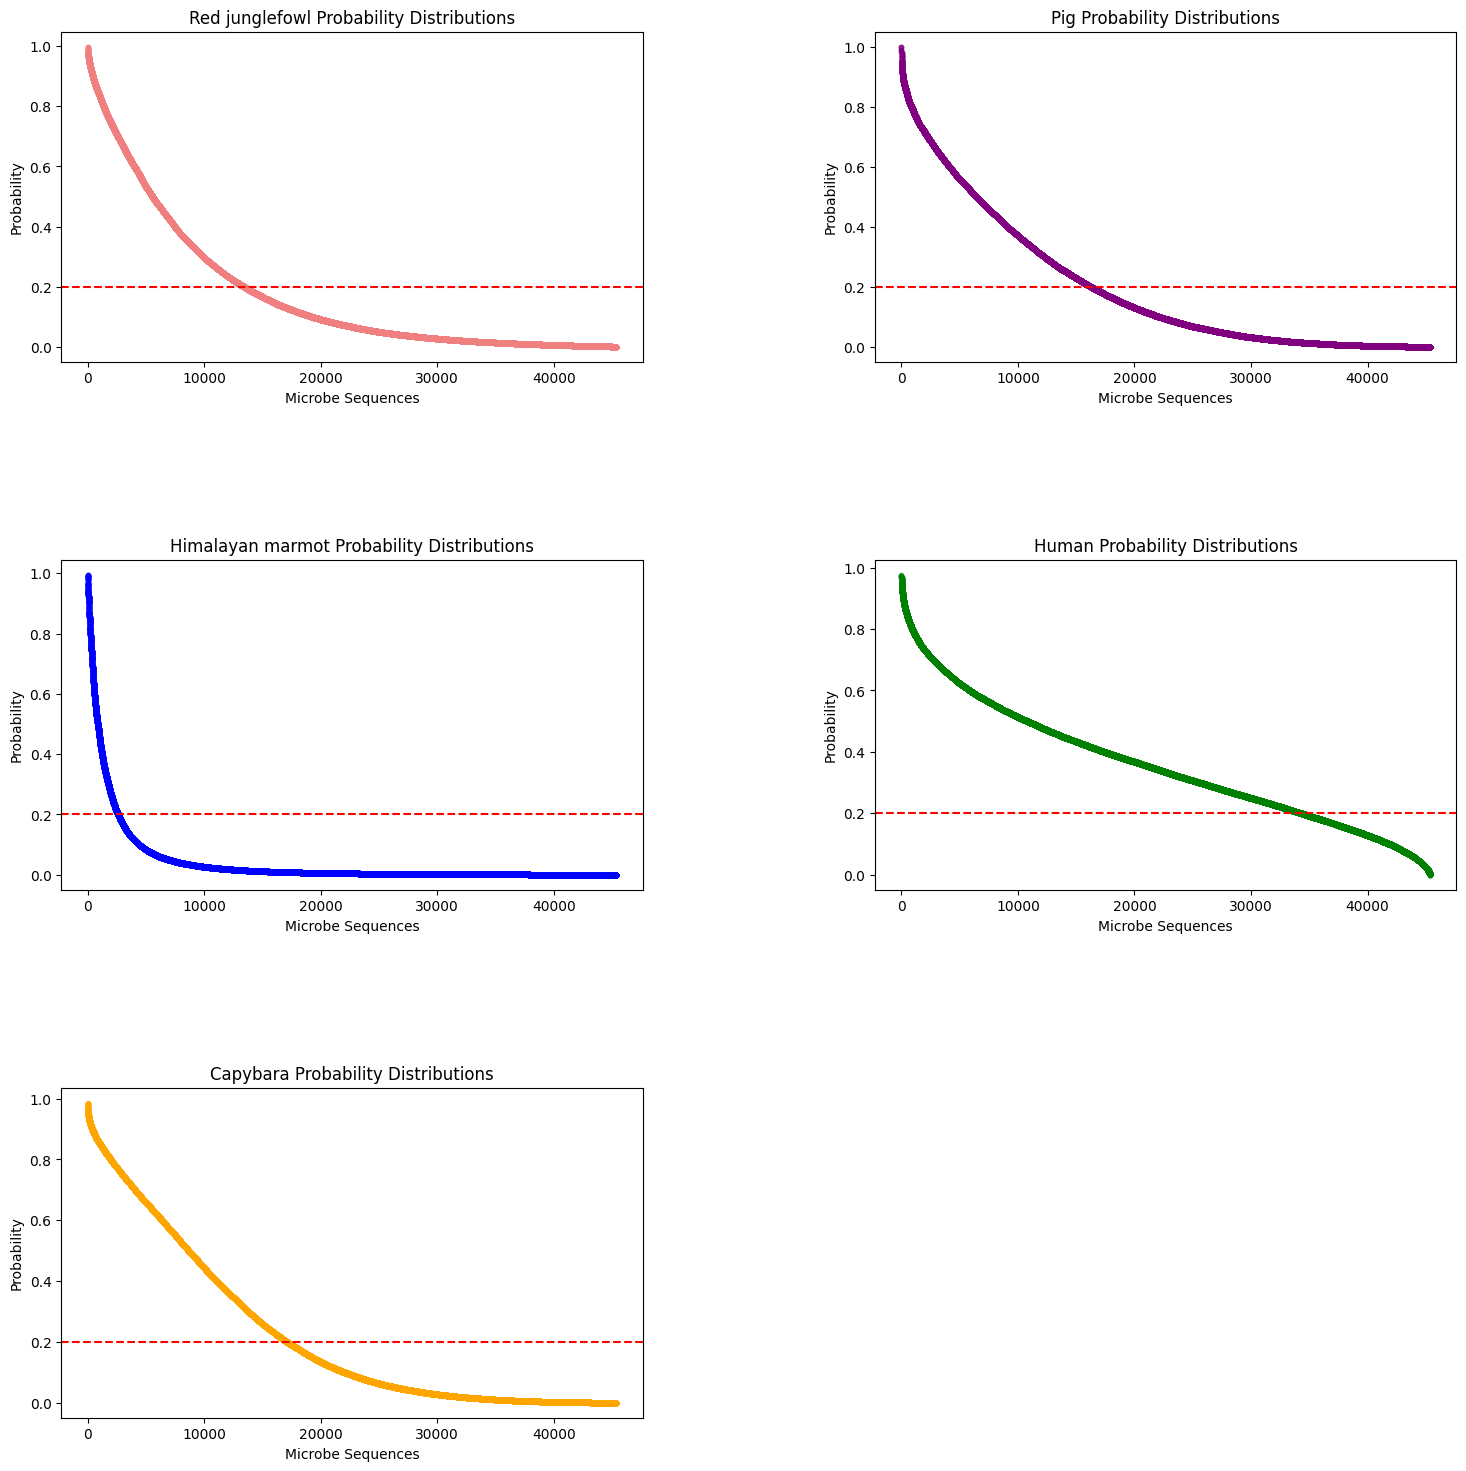

In [14]:
plt.figure(figsize=(18, 18))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

threshold = 0.01
hosts = ['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']
colors = ['lightcoral', 'purple', 'blue', 'green', 'orange']

for i, (host, color) in enumerate(zip(hosts, colors)):
    plt.subplot(3, 2, i + 1)
    
    y_vals = df[host].sort_values(ascending=False).values
    x_vals = range(len(y_vals))
    
    plt.scatter(x_vals, y_vals, color=color, label=host, s=10, alpha=0.6)
    plt.title(f'{host} Probability Distributions')
    plt.xlabel('Microbe Sequences')
    plt.ylabel('Probability')
    plt.axhline(y=0.2, color='r', linestyle='--')

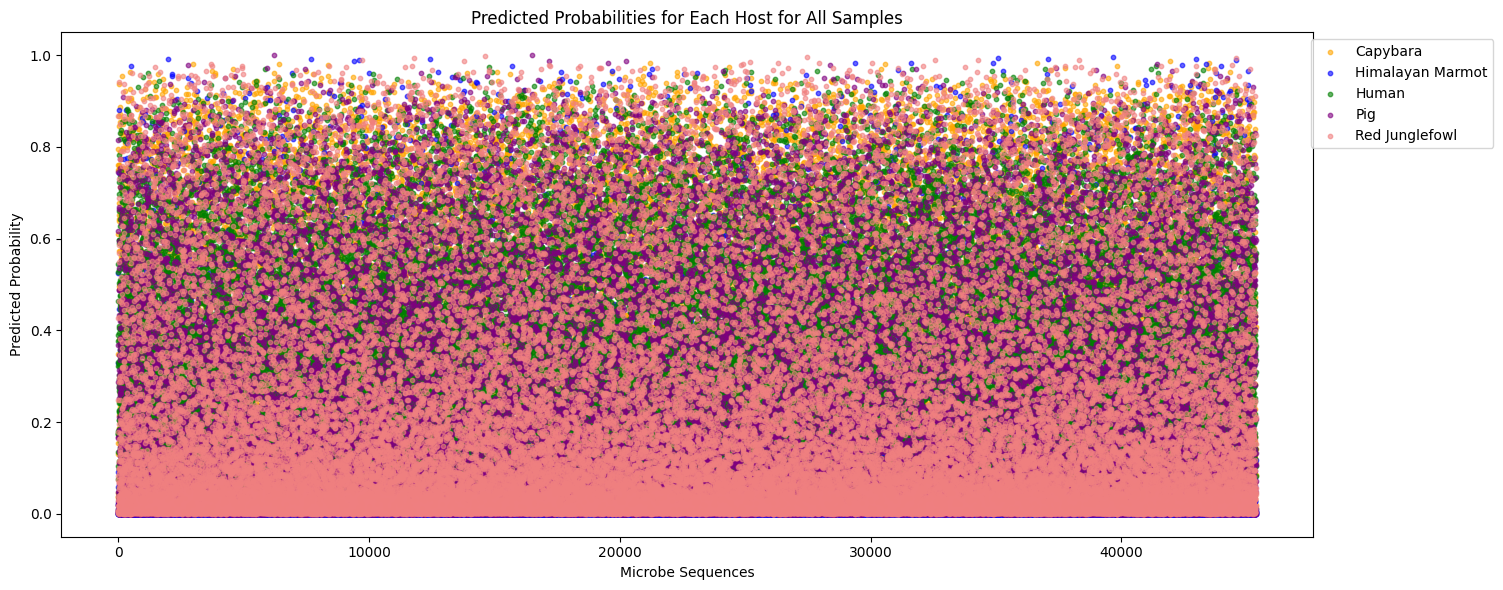

In [15]:
plt.figure(figsize=(15, 6))

x = df.index

# plot each host's probability as colored dots
plt.scatter(x, df['Capybara'], color='orange', label='Capybara', s=10, alpha=0.6)
plt.scatter(x, df['Himalayan marmot'], color='blue', label='Himalayan Marmot', s=10, alpha=0.6)
plt.scatter(x, df['Human'], color='green', label='Human', s=10, alpha=0.6)
plt.scatter(x, df['Pig'], color='purple', label='Pig', s=10, alpha=0.6)
plt.scatter(x, df['Red junglefowl'], color='lightcoral', label='Red Junglefowl', s=10, alpha=0.6)

# add labels, legend, title
plt.title('Predicted Probabilities for Each Host for All Samples')
plt.xlabel('Microbe Sequences')
plt.ylabel('Predicted Probability')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

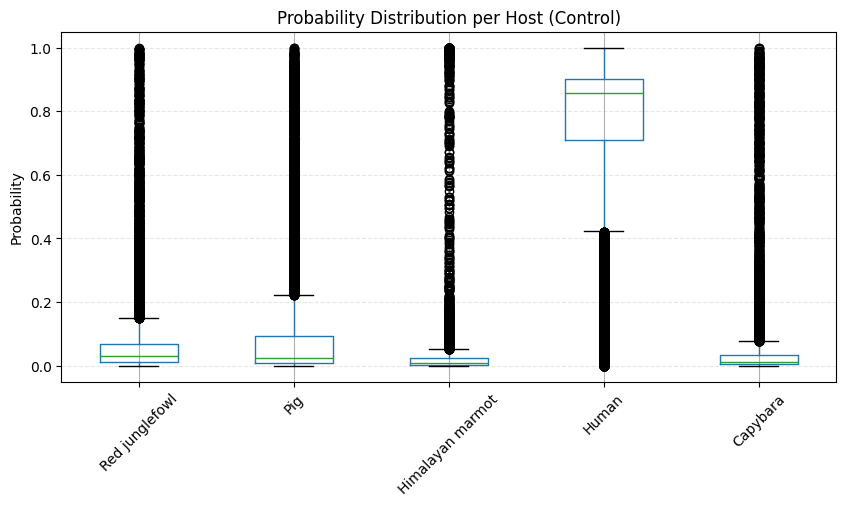

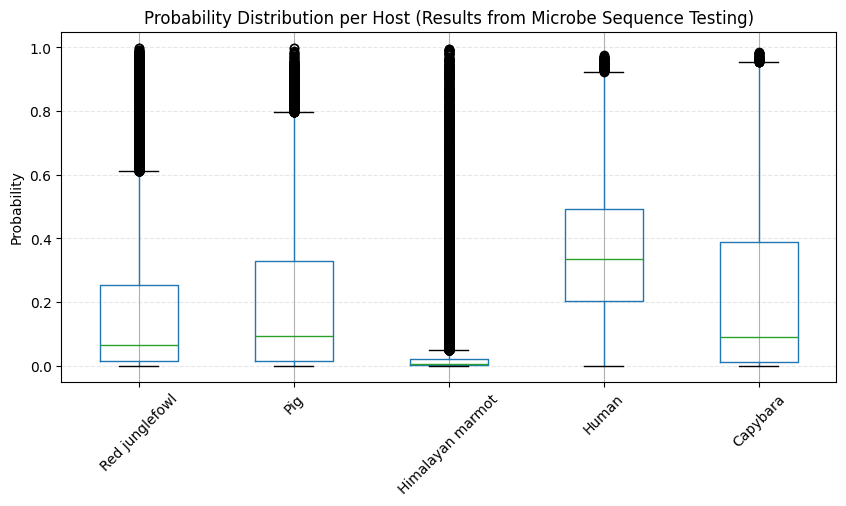

In [16]:
# box plots for control (haven trained on uniref90 filtered for vertebrate sequences)
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
vert_df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']].boxplot()
plt.ylabel("Probability")
plt.title("Probability Distribution per Host (Control)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

# box plots for plant sequence testing (experimenting on haven with unseen hosts/potentially unseen viruses as well)
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 2)
df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']].boxplot()
plt.ylabel("Probability")
plt.title("Probability Distribution per Host (Results from Microbe Sequence Testing)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

As shown in the above box plots displaying the probability distributions for the five common hosts, Red junglefowl, Capybara, and Pig exhibit a right skewed distribution, where most of the probabilities fall below 0.5. The Himalayan marmot has numerous outliers. The Human host distribution has a mean of roughly 0.35 and displays a more normal distribution than its counterparts.

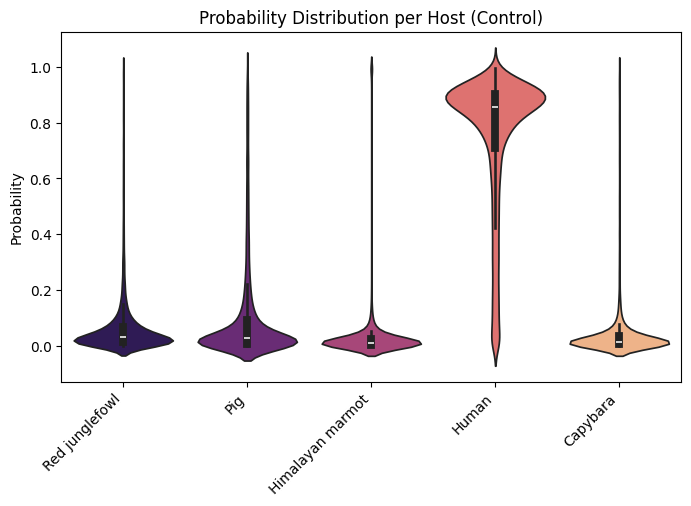

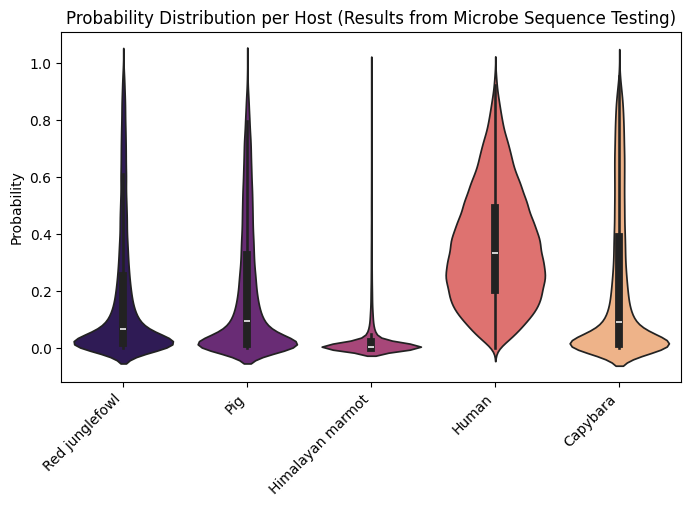

In [17]:
# same concept as above, however different visualization (violin plots)
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
sns.violinplot(vert_df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']], palette='magma')
plt.title('Probability Distribution per Host (Control)')
plt.ylabel('Probability')
plt.xticks(ha='right', rotation=45)
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 2)
sns.violinplot(df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']], palette='magma')
plt.title('Probability Distribution per Host (Results from Microbe Sequence Testing)')
plt.ylabel('Probability')
plt.xticks(ha='right', rotation=45)
plt.show()

### Statistical Analysis

##### Computing Summary Statistics & Visualizing Uncertainty via Entropy

In [18]:
# compute summary stats
def compute_stats(df, group_name, hosts):
    means = df[hosts].mean()
    stds = df[hosts].std()
    summary = means.round(3).astype(str) + " ± " + stds.round(3).astype(str)
    return pd.DataFrame({'Mean ± Std': summary}, index=hosts).rename(columns={'Mean ± Std': group_name})

stats = compute_stats(df, "Microbe", hosts)
summary_table = pd.concat([stats], axis=1)
print(summary_table)

                        Microbe
Red junglefowl    0.178 ± 0.232
Pig               0.199 ± 0.231
Himalayan marmot  0.041 ± 0.116
Human             0.358 ± 0.196
Capybara          0.224 ± 0.265


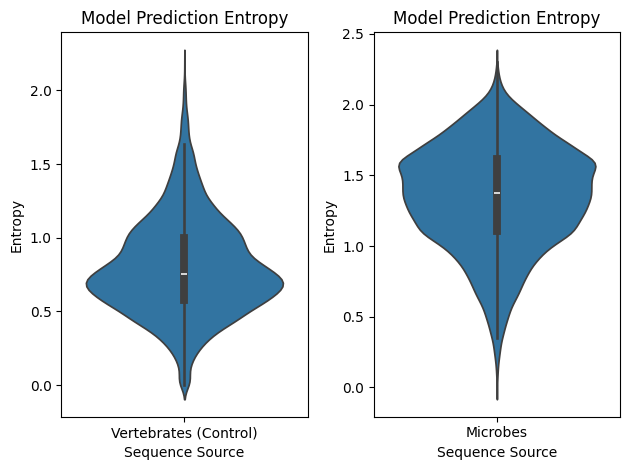

In [19]:
# define entropy function (measures the uncertainty in HAVEN's predicted host probabilities for a given viral sequencce)
# low entropy means max confidence, high means uncertain between 2 classes, outlier means maximum confusion
def add_entropy_column(df, hosts):
    df = df.copy()
    df['entropy'] = df[hosts].apply(lambda row: entropy(row.values, base=2), axis=1)
    return df

df_microbe = add_entropy_column(df, hosts)
df_microbe['group'] = 'Microbes'

df_vert = add_entropy_column(vert_df, hosts)
df_vert['group'] = 'Vertebrates (Control)'

plt.subplot(1, 2, 1)
sns.violinplot(data=df_vert, x='group', y='entropy')
plt.title("Model Prediction Entropy")
plt.xlabel("Sequence Source")
plt.ylabel("Entropy")

plt.subplot(1, 2, 2)
sns.violinplot(data=df_microbe, x='group', y='entropy')
plt.title("Model Prediction Entropy")
plt.xlabel("Sequence Source")
plt.ylabel("Entropy")


plt.tight_layout()
plt.show()

In [20]:
entropy_stats = df_microbe.groupby('group')['entropy'].describe()
print(entropy_stats)

            count      mean       std       min       25%       50%       75%  \
group                                                                           
Microbes  45351.0  1.345554  0.369236  0.002467  1.107435  1.373875  1.614798   

              max  
group              
Microbes  2.30138  


It is reasonable that the average entropy for these data is between 1.25 to 1.75. HAVEN is  uncertain and inconclusive as there are more diverse and confusing inputs. It is seeing very few familiar patterns in these sequences and predicting those with rough confidence.

**Note**: scipy.stats.entropy function calculates Shannon entropy (H = - Σ (pk * log(pk)))

### Predictive Trends
##### Does HAVEN classify certain plant hosts repeatedly as the same host or assign different hosts (from the five common hosts) in multiple instances?

In [25]:
# get the predicted host with the highest probability for each row
df['Top_Host'] = df[hosts].idxmax(axis=1)

results = []

# create columns for storing microbe host, if its always the same host, top host, and the number of sequences
for microbe in df['y_true'].unique():
    subset = df[df['y_true'] == microbe]
    top_host = subset['Top_Host'].iloc[0]
    always_same = (subset['Top_Host'] == top_host).all()
    
    results.append({
        'Microbe': microbe,
        'Always_Same_Host': always_same,
        'Top_Host': top_host,
        'Num_Sequences': len(subset)
    })

# convert results into data frame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Num_Sequences', ascending=False)

print(results_df)


                      Microbe  Always_Same_Host          Top_Host  \
10           Escherichia coli             False    Red junglefowl   
13       Aeromonas hydrophila             False          Capybara   
5               Vibrio lentus             False  Himalayan marmot   
24     Ralstonia solanacearum             False  Himalayan marmot   
11          Erwinia amylovora             False               Pig   
..                        ...               ...               ...   
482   Alternaria brassicicola              True             Human   
477     Diplodia scrobiculata              True             Human   
476    Erysiphe cichoracearum              True             Human   
474  Streptomyces avermitilis              True    Red junglefowl   
553     Penicillium digitatum              True  Himalayan marmot   

     Num_Sequences  
10            1865  
13            1451  
5             1135  
24            1113  
11            1099  
..             ...  
482              1  
477

/localscratch/ipykernel_915238/3406867479.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_host_counts.index, y=top_host_counts.values, palette='magma')


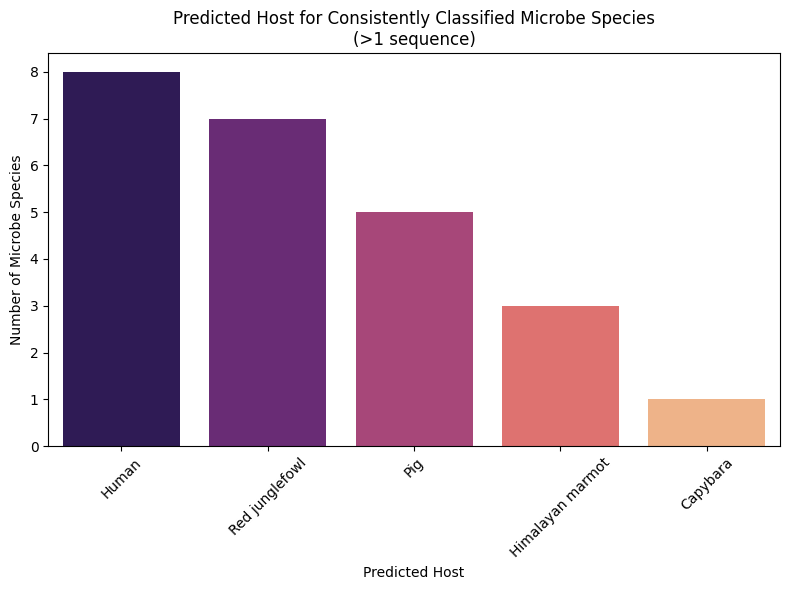

In [27]:
# defined a "consistent prediction" when it is predicting the same host for more than 1 sequence
consistent_predictions = results_df[
    (results_df['Always_Same_Host'] == True) &
    (results_df['Num_Sequences'] > 1)
]

# count top predicted hosts
top_host_counts = consistent_predictions['Top_Host'].value_counts()

# plot, add title and axis labels
plt.figure(figsize=(8,6))
sns.barplot(x=top_host_counts.index, y=top_host_counts.values, palette='magma')

plt.title('Predicted Host for Consistently Classified Microbe Species\n(>1 sequence)')
plt.xlabel('Predicted Host')
plt.ylabel('Number of Microbe Species')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

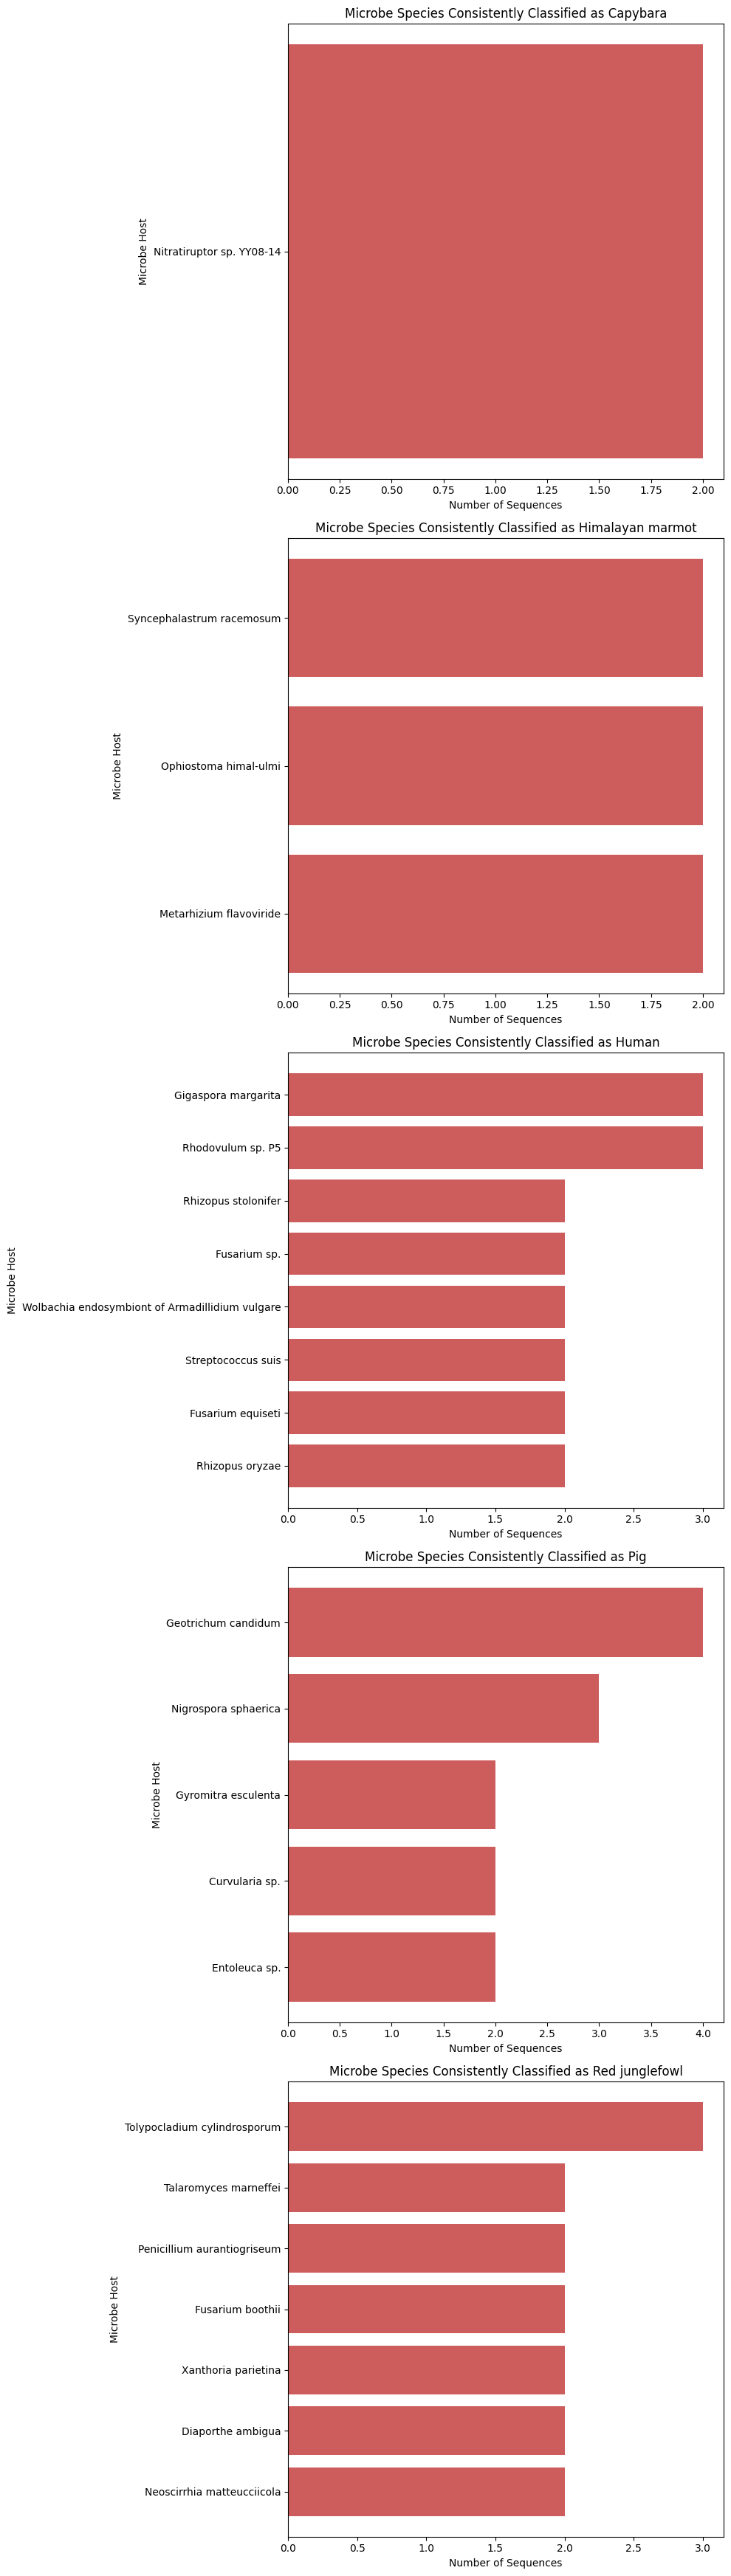

In [29]:
grouped = consistent_predictions.groupby('Top_Host')
hosts = grouped.groups.keys()
n_hosts = len(hosts)

# create subplots
fig, axes = plt.subplots(n_hosts, 1, figsize=(10, 7 * n_hosts), sharex=False)

if n_hosts == 1:
    axes = [axes]

# function to retrieve actual microbe host from the consistently predicted five common hosts
for ax, host in zip(axes, hosts):
    group = grouped.get_group(host).sort_values(by='Num_Sequences', ascending=False)
    microbe_names = group['Microbe']
    counts = group['Num_Sequences']
    
    ax.barh(microbe_names, counts, color='indianred')
    ax.set_title(f'Microbe Species Consistently Classified as {host}')
    ax.set_xlabel('Number of Sequences')
    ax.set_ylabel('Microbe Host')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

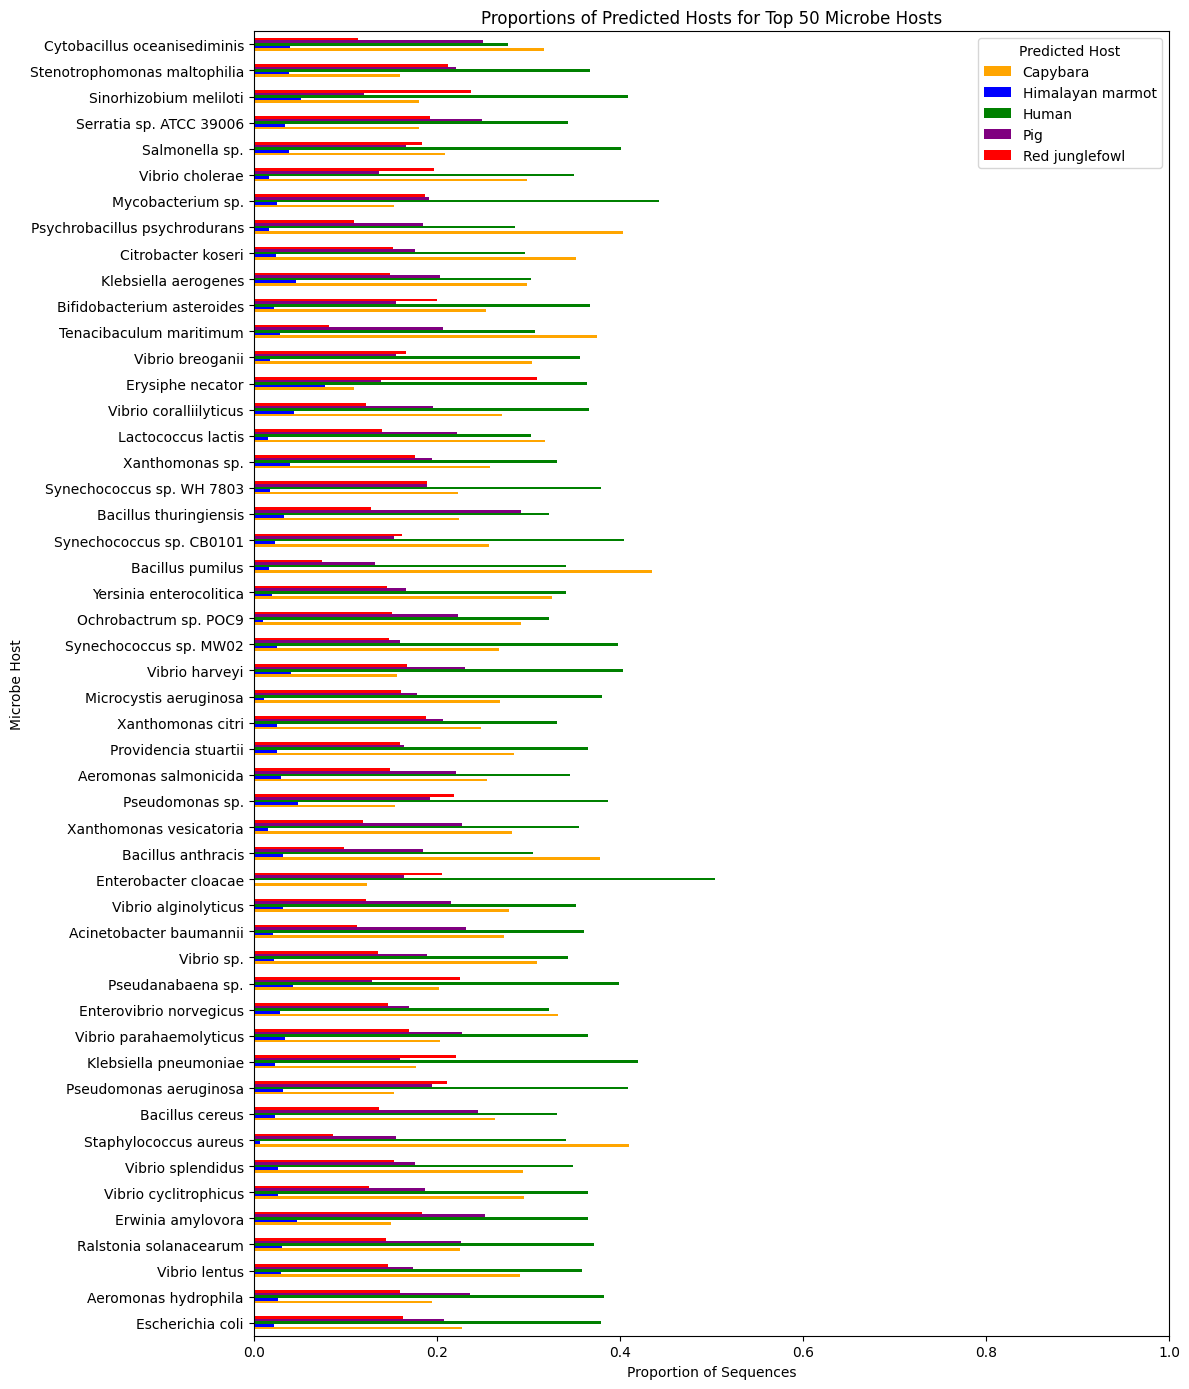

In [31]:
# get the top 50 most prevalent microbes in the dataset (out of 554 total unique microbe hosts)
top_50_microbe = df['y_true'].value_counts().head(50).index
filtered_df = df[df['y_true'].isin(top_50_microbe)].copy()

# count how many microbe sequences were reported as a specific host (of the five common hosts)
counts = filtered_df.groupby(['y_true', 'Top_Host']).size().reset_index(name='count')

# count the total number of sequences for each microbe host
total_per_microbe = filtered_df.groupby('y_true').size().reset_index(name='total')

# perform a merge to combine two datasets (one containing the counts and the other number of sequences) together on the y_true column
# create a proportion column that divides count by total number of sequences
merged = counts.merge(total_per_microbe, on='y_true')
merged['proportion'] = merged['count'] / merged['total']

# pivot/rotate the table so that y_true is the index and columns are Top_Host, values are the proportion
pivot_df = merged.pivot(index='y_true', columns='Top_Host', values='proportion').fillna(0)
pivot_df = pivot_df.loc[top_50_microbe]

# plot the horizontal bar plot showing five bars for each microbe host
ax = pivot_df.plot(
    kind='barh',
    stacked=False,
    figsize=(12, 14),
    color={
        'Capybara': 'orange',
        'Himalayan marmot': 'blue',
        'Human': 'green',
        'Pig': 'purple',
        'Red junglefowl': 'red',
    }
)

# configure the barplots to one graph display
plt.xlabel('Proportion of Sequences')
plt.xlim(0, 1)
plt.ylabel('Microbe Host')
plt.title('Proportions of Predicted Hosts for Top 50 Microbe Hosts')
plt.legend(title='Predicted Host', loc='upper right')

plt.tight_layout()
plt.show()

**Bar Chart Analysis:**
* Enterobacter cloacae (gram-negative, rod-shaped bacterium, found mainly in animal/human intestinal tracts) highest proportion of sequences predicted as Human
* Bacillus thuringiensis (gram-positive, soil-dwelling bacterium) highest proportion of sequences predicted as Pig
* Bacillus pumilus (gram-positive, spore-forming bacillus found commonly in the soil) highest proportion of sequences predicted as Capybara
* Erysiphe necator (fungus that causes powdery mildew of grapes) highest proportion of sequences predicted as Red junglefowl
* Erysiphe necator (fungus that causes powdery mildew of grapes) highest proportion of sequences predicted as Himalayan marmot

**Note:** idxmax function was used to retrieve the largest proportions for each of the five common hosts, therefore some hosts listed above do not appear on the bar chart graph

### Observations & Conclusions

The results show that HAVEN does decently well in predicting the host given the viral protein sequences of microbe virus', ones it has not seen before in training. We expect that the model acts 'confused' when given these microbe sequences and by the violin plot we observe this 'confusion' due to the increased range of probabilities and wider distributions. Some interesting findings throughout the exploratory process include Geotrichum canidum (a fungus, member of the human microbiome) was misinterpreted as a Pig four times, the highest number of all misclassifications. HAVEN consistently predicts the host as a Human, which could be potentially due to more extensive and comprehensive training data for human virus'. Another surprising finding is that HAVEN is confident that a majority of these viral protein sequences do not infect Himalayan marmots which could be due to limited data in that area, but also indicative of HAVEN's ability to make accurate and confident predictions.